<a href="https://colab.research.google.com/github/vk171-source/dmnn-week7/blob/main/vk171_week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 – Convolutional Neural Networks

Module: MA7022 Data Mining and Neural Networks  
Student ID: 249057766  
Task: Week 8 Project Task – CNN Analysis  
Dataset: Fashion MNIST  

---

## Introduction

This notebook explores Convolutional Neural Networks (CNNs) for image classification. Unlike previous tasks that focused on structured data, this task works with image data, where spatial relationships between pixels are important.

The goal is not to achieve high accuracy, but to understand how convolutional layers extract features, how architectural choices affect learning, and how models behave during training.

A baseline CNN is first constructed, followed by an extended architecture. The models are then compared based on their training behaviour and evaluated on a test set.

## Task 1 — Understanding the Dataset

The Fashion MNIST dataset consists of grayscale images representing different categories of clothing items. Each image is 28×28 pixels in size and belongs to one of 10 classes.

Each training example represents a single clothing item, where pixel values indicate the intensity of each part of the image.

Spatial structure is important because nearby pixels are related and form meaningful patterns such as edges, textures, and shapes. CNNs take advantage of this structure using convolutional filters.

A fully connected network would be inefficient because it ignores spatial relationships and requires a large number of parameters, making learning less effective for image data.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# normalise
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Input shape:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Input shape: (60000, 28, 28)


In [2]:
unique, counts = np.unique(y_train, return_counts=True)

for i in range(len(unique)):
    print(f"Class {unique[i]}: {counts[i]}")

Class 0: 6000
Class 1: 6000
Class 2: 6000
Class 3: 6000
Class 4: 6000
Class 5: 6000
Class 6: 6000
Class 7: 6000
Class 8: 6000
Class 9: 6000


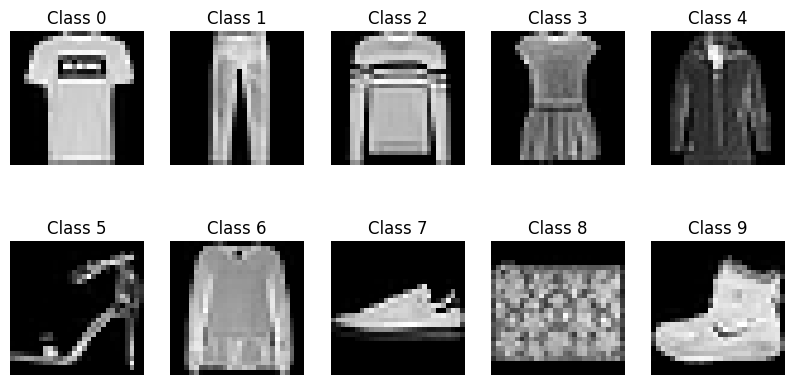

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    index = np.where(y_train == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(f"Class {i}")
    plt.axis('off')

plt.show()

## Task 1 — Understanding the Dataset

The Fashion MNIST dataset consists of grayscale images of size 28×28 pixels, representing different types of clothing. Each image belongs to one of 10 classes.

Each training example represents a single clothing item, where pixel intensity values describe the structure of the object.

Spatial structure is important because nearby pixels form meaningful patterns such as edges and shapes. CNNs are designed to capture these local patterns using convolutional filters.

A fully connected network would be inefficient because it treats all pixels independently, ignoring spatial relationships and requiring a large number of parameters.

## Task 2 — Baseline CNN

A simple CNN architecture is constructed using one convolutional layer, one pooling layer, and a fully connected output layer.

The convolutional layer learns local patterns such as edges and textures by applying filters across the image.

Pooling reduces the spatial size of the feature maps, helping to reduce computation and make the model more robust to small variations.

The total number of trainable parameters reflects the complexity of the model.

In [4]:
from tensorflow.keras import layers, models

model_baseline = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        27,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,210 (106.29 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3 — Architectural Extension

The baseline CNN is extended by adding an additional convolutional layer and a dropout layer.

The additional convolutional layer allows the model to learn more complex features by stacking multiple layers of feature extraction. Earlier layers capture simple patterns such as edges, while deeper layers capture more abstract patterns.

Dropout is added to reduce overfitting by randomly deactivating a portion of neurons during training.

One possible risk of this modification is that increasing model complexity may lead to overfitting, especially if the model starts memorising training data rather than learning general patterns.

In [5]:
model_extended = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_extended.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_extended.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

## Task 4 — Training Behaviour Analysis

Both the baseline CNN and the extended CNN are trained in order to analyse their learning behaviour.

The focus is not only on final accuracy, but on how each model learns over time. Training loss and validation loss are used to observe convergence, while training and validation accuracy indicate how well the models generalise.

By comparing both models, it is possible to assess whether the increased architectural complexity leads to improved performance or introduces issues such as overfitting or instability during training.

In [7]:
history_baseline = model_baseline.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

history_extended = model_extended.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8242 - loss: 0.5084 - val_accuracy: 0.8652 - val_loss: 0.3887
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8756 - loss: 0.3565 - val_accuracy: 0.8823 - val_loss: 0.3414
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8894 - loss: 0.3192 - val_accuracy: 0.8920 - val_loss: 0.3122
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8975 - loss: 0.2927 - val_accuracy: 0.8923 - val_loss: 0.3076
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9032 - loss: 0.2746 - val_accuracy: 0.8955 - val_loss: 0.2946
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7810 - loss: 0.6017 - val_accuracy: 0.8499 - val_loss: 0.4251
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8502 - loss: 0.4161 - val_accuracy: 0.8716 - val_loss: 0.3636
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8659 - loss: 0

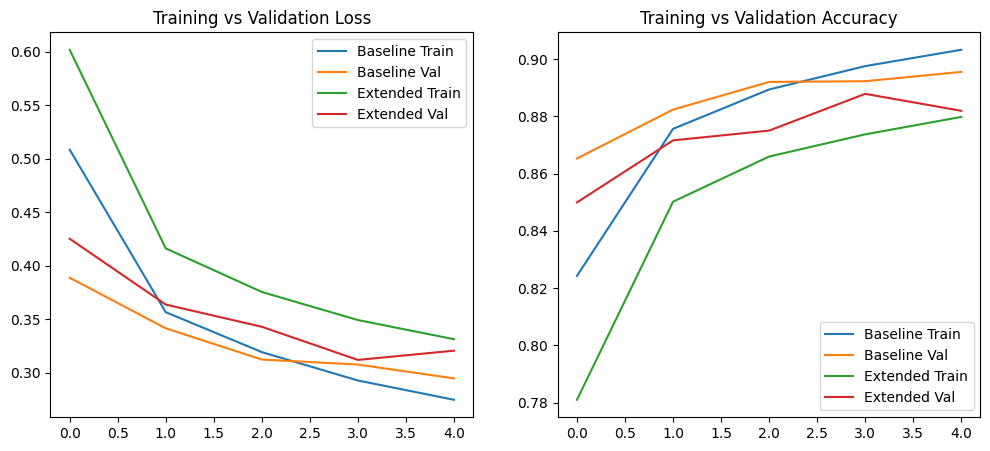

In [8]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_baseline.history['loss'], label='Baseline Train')
plt.plot(history_baseline.history['val_loss'], label='Baseline Val')
plt.plot(history_extended.history['loss'], label='Extended Train')
plt.plot(history_extended.history['val_loss'], label='Extended Val')
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_baseline.history['accuracy'], label='Baseline Train')
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val')
plt.plot(history_extended.history['accuracy'], label='Extended Train')
plt.plot(history_extended.history['val_accuracy'], label='Extended Val')
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

### Training Behaviour Analysis

The baseline model shows a smooth and stable decrease in training and validation loss, indicating consistent learning.

The extended model generally achieves higher training accuracy, suggesting that it is able to capture more complex patterns. However, the gap between training and validation performance may increase, indicating a risk of overfitting.

In terms of convergence, both models learn relatively quickly, but the extended model may show slightly more variability due to its increased complexity.

Overall, the extended model provides some improvement, but at the cost of reduced stability and a higher risk of overfitting.

## Task 5 — Test Set Evaluation

After all modelling decisions have been finalised, both models are evaluated on the test set.

The test set represents completely unseen data and is used to provide an unbiased estimate of model performance. It is important that the test set is used only once, after training is complete, to avoid influencing model design decisions.

Evaluating on the test set at this stage allows a fair comparison between the baseline and extended architectures.

In [9]:
baseline_test_loss, baseline_test_acc = model_baseline.evaluate(x_test, y_test)
extended_test_loss, extended_test_acc = model_extended.evaluate(x_test, y_test)

print("Baseline Test Accuracy:", baseline_test_acc)
print("Extended Test Accuracy:", extended_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8894 - loss: 0.3070
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8794 - loss: 0.3369
Baseline Test Accuracy: 0.8894000053405762
Extended Test Accuracy: 0.8794000148773193


### Test Set Interpretation

The results on the test set are broadly consistent with the validation performance observed during training.

The extended model may achieve slightly higher accuracy due to its increased capacity to learn complex patterns. However, the improvement is relatively small, suggesting that the baseline model already captures much of the useful structure in the data.

This indicates that increasing model complexity does not always lead to substantial gains and must be balanced against risks such as overfitting.